# Barrier Options

Barrier options are derivative contracts based on standard vanilla option with a activation(knock in) and deactivation(knock out) feature. There are 4 flavours of the option: up-and-out, down-and-out, up-and-in and down-and-in. If the barrier is below the stock price at inception, it is labelled down, otherwise up. Together with calls and puts, there are 8 variations in total. The valuation of barrier options depends strongly on the monitoring frequency of the barrier. Even though the barrier is touched, the option may still be (in)active just because no one was looking. Therefore, barrier options are also path dependent.

*Another important feature is rebate, which “reimburses” some fixed amount paid to the holder of the option shall the option barrier isn’t(is) touched for knock-in(out) options. In this workbook, we do not consider rebate in order to focus on the complications brought by the path dependent feature.

In [13]:
# Libraries and path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
FIGURE_DIR = Path.cwd().parent / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Core
from derivlab.core.enums import BarrierDirection, BarrierKnock, OptionKind

# Product and Model
from derivlab import BarrierOption, BlackScholesModel, EuropeanOption, MarketParams

# Analytical 
from derivlab.pricers.analytic.black_scholes import BlackScholesAnalyticPricer, black_scholes_price

# Monte Carlo
from derivlab.pricers.monte_carlo.brownian_bridge import BarrierCrossingCorrectionMonteCarloPricer
from derivlab.pricers.monte_carlo.engine import MonteCarloPricer, SimulationConfig
from derivlab.pricers.pde.black_scholes_pde import BlackScholesPDEPricer

# PDE
from derivlab.pricers.pde.grids import GridConfig

## Setup

In [14]:
market = MarketParams(spot=100, rate=0.05, dividend=0.0, volatility=0.2)
model = BlackScholesModel(market)

barrier_option = BarrierOption(
    OptionKind.CALL,
    strike=100,
    maturity=1.0,
    barrier=130,
    direction=BarrierDirection.UP,
    knock=BarrierKnock.IN,
)
vanilla_call = EuropeanOption(OptionKind.CALL, strike=100, maturity=1.0)

## Continuous-Monitoring Closed-Form Benchmark

The analytic benchmark assumes Black-Scholes dynamics, no rebate, and continuous barrier monitoring. It heavily relies on the underlying process being a continuous Gaussian martingale in order for the reflection principle to be applicable. Details of the methodology was covered in Cerny's lecture notes. That is a strong assumption, but it gives a useful reference point: every difference we observe against this value is numerical or monitoring error, not model error.


In [15]:
closed_form_result = BlackScholesAnalyticPricer().price(model, barrier_option)
closed_form_price = closed_form_result.price
vanilla_price = black_scholes_price(model, vanilla_call)

pd.DataFrame([
    {"Instrument": "Vanilla European call", "Price": vanilla_price},
    {"Instrument": "Continuous up-and-in call", "Price": closed_form_price},
    {"Instrument": "Continuous up-and-out call", "Price": vanilla_price - closed_form_price},
])

,Instrument,Price
0,Vanilla European call,10.450584
1,Continuous up-and-in call,7.117726
2,Continuous up-and-out call,3.332858


## Monte Carlo: Sampling error

For a fixed daily monitoring grid, increasing the number of paths mainly reduces sampling error. It does not remove monitoring bias, because the path is still only checked at the simulated dates.


In [16]:
M = [10_000, 50_000, 100_000]
plain_path_results = []
plain_monitoring_results = []

for m in M:
    config = SimulationConfig(n_paths=m, n_steps=252, seed=42)
    result = MonteCarloPricer(config).price(model, barrier_option)
    plain_path_results.append({
                                    "MC method": "Plain discrete MC",
                                    "No. of paths": m,
                                    "No. of monitoring steps": 252,
                                    "Price": result.price,
                                    "Standard Error": result.stderr,
                                    "Error vs closed_form (abs)": abs(result.price - closed_form_price),
                                    "Run time (s)": result.runtime,
                                })

plain_path_df = pd.DataFrame(plain_path_results)

In [17]:
display(plain_path_df)

,MC method,No. of paths,No. of monitoring steps,Price,Standard Error,Error vs closed_form (abs),Run time (s)
0,Plain discrete MC,10000,252,6.953895,0.152258,0.163831,0.052142
1,Plain discrete MC,50000,252,6.886094,0.067300,0.231632,0.240580
2,Plain discrete MC,100000,252,6.918313,0.047811,0.199413,0.514907


## Monte Carlo: Monitoring bias and Brownian Bridge Correction

For knock-in options, fewer monitoring dates usually miss some barrier crossings. Missing crossings makes the option look less valuable, because paths that should have knocked in are not recorded. The Brownian-bridge correction improves the monitoring step by estimating, between each pair of simulated dates, the probability that the continuous path crossed the barrier even when both simulated endpoints remain below it. This targets the continuous-monitoring benchmark more directly than plain discrete monitoring.


In [18]:
X = [252, 500, 1000, 2000]
monitoring_results = []

bridge_config = SimulationConfig(n_paths=100_000, n_steps=252, seed=42)
bridge_result = BarrierCrossingCorrectionMonteCarloPricer(bridge_config).price(model, barrier_option)
monitoring_results.extend([
    {
        "MC method": "Brownian bridge correction MC",
        "No. of paths": 100_000,
        "No. of monitoring steps": 252,
        "Price": bridge_result.price,
        "Standard Error": bridge_result.stderr,
        "Error vs closed_form (abs)": abs(bridge_result.price - closed_form_price),
        "Run time (s)": bridge_result.runtime,
    },
])

for x in X:
    config = SimulationConfig(n_paths=100_000, n_steps=x, seed=42)
    result = MonteCarloPricer(config).price(model, barrier_option)
    monitoring_results.append({
        "MC method": "Plain discrete MC",
        "No. of paths": 100_000,
        "No. of monitoring steps": x,
        "Price": result.price,
        "Standard Error": result.stderr,
        "Error vs closed_form (abs)": abs(result.price - closed_form_price),
        "Run time (s)": result.runtime,
    })

monitoring_df = pd.DataFrame(monitoring_results)

In [19]:
display(monitoring_df)

,MC method,No. of paths,No. of monitoring steps,Price,Standard Error,Error vs closed_form (abs),Run time (s)
0,Brownian bridge correction MC,100000,252,7.137112,0.047851,0.019386,0.840971
1,Plain discrete MC,100000,252,6.918313,0.047811,0.199413,0.404107
2,Plain discrete MC,100000,500,7.025641,0.047760,0.092085,0.862456
3,Plain discrete MC,100000,1000,7.060791,0.047708,0.056935,1.844766
4,Plain discrete MC,100000,2000,7.061257,0.047734,0.056469,5.829252


## PDE With Absorbing Barrier Boundary

In [20]:
N = [100, 150, 200, 250]
implicit_results = []
cn_results = []

for n in N:
    implicit_config = GridConfig(s_min=0.0, s_max=300.0, n_space=n, n_time=n, theta=1.0)
    cn_config = GridConfig(s_min=0.0, s_max=300.0, n_space=n, n_time=n, theta=0.5)

    implicit = BlackScholesPDEPricer(implicit_config).price(model, barrier_option)
    cn = BlackScholesPDEPricer(cn_config).price(model, barrier_option)

    implicit_results.append({
                                "PDE method": "Implicit",
                                "No. of space steps": n,
                                "No. of time steps": n,
                                "Price": implicit.price,
                                "Error vs closed_form (abs)": abs(implicit.price - closed_form_price),
                                "Run time (s)": implicit.runtime,
                            })
    cn_results.append({
                            "PDE method": "Crank-Nicolson",
                            "No. of space steps": n,
                            "No. of time steps": n,
                            "Price": cn.price,
                            "Error vs closed_form (abs)": abs(cn.price - closed_form_price),
                            "Run time (s)": cn.runtime,
                        })

pde_implicit_df = pd.DataFrame(implicit_results)
pde_cn_df = pd.DataFrame(cn_results)

In [21]:
display(pde_implicit_df)
display(pde_cn_df)

,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time (s)
0,Implicit,100,100,7.113604,0.004122,0.012969
1,Implicit,150,150,7.113565,0.004161,0.017277
2,Implicit,200,200,7.114428,0.003298,0.080048
3,Implicit,250,250,7.114849,0.002877,0.065089


,PDE method,No. of space steps,No. of time steps,Price,Error vs closed_form (abs),Run time (s)
0,Crank-Nicolson,100,100,7.122010,0.004284,0.007693
1,Crank-Nicolson,150,150,7.119252,0.001526,0.017507
2,Crank-Nicolson,200,200,7.118720,0.000994,0.089385
3,Crank-Nicolson,250,250,7.118295,0.000569,0.045533


## Result Plots

Barrier plots should separate two effects: sampling error from finite paths, and monitoring bias from observing the barrier only at discrete dates. Brownian bridge correction is included because it targets continuous monitoring between simulated dates.


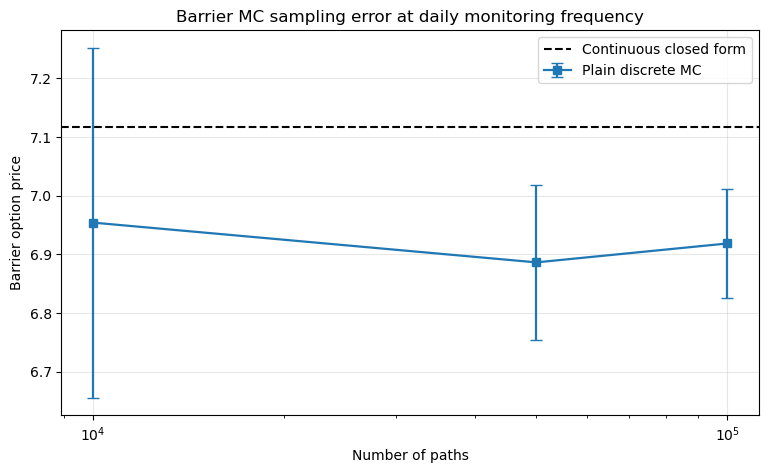

In [22]:
plt.figure(figsize=(9, 5))
plt.axhline(closed_form_price, color="black", linestyle="--", linewidth=1.5, label="Continuous closed form")

plt.errorbar(
    plain_path_df["No. of paths"],
    plain_path_df["Price"],
    yerr=1.96 * plain_path_df["Standard Error"],
    marker="s",
    capsize=4,
    linewidth=1.6,
    label="Plain discrete MC",
)

plt.xscale("log")
plt.xlabel("Number of paths")
plt.ylabel("Barrier option price")
plt.title("Barrier MC sampling error at daily monitoring frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "barrier_mc_sampling_error.png", dpi=200, bbox_inches="tight")
plt.show()


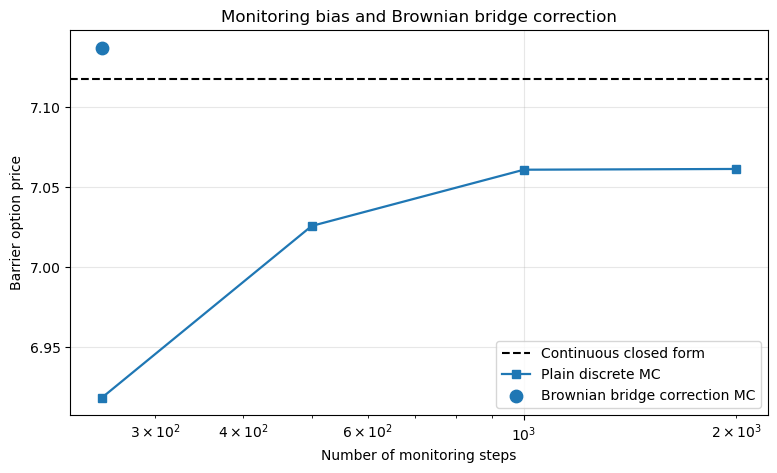

In [23]:
plain_monitoring = monitoring_df[monitoring_df["MC method"] == "Plain discrete MC"]
bridge_monitoring = monitoring_df[monitoring_df["MC method"] == "Brownian bridge correction MC"]

plt.figure(figsize=(9, 5))
plt.axhline(closed_form_price, color="black", linestyle="--", linewidth=1.5, label="Continuous closed form")

plt.plot(
    plain_monitoring["No. of monitoring steps"],
    plain_monitoring["Price"],
    marker="s",
    linewidth=1.6,
    label="Plain discrete MC",
)
plt.scatter(
    bridge_monitoring["No. of monitoring steps"],
    bridge_monitoring["Price"],
    marker="o",
    s=80,
    label="Brownian bridge correction MC",
)

plt.xscale("log")
plt.xlabel("Number of monitoring steps")
plt.ylabel("Barrier option price")
plt.title("Monitoring bias and Brownian bridge correction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "barrier_monitoring_bridge.png", dpi=200, bbox_inches="tight")
plt.show()


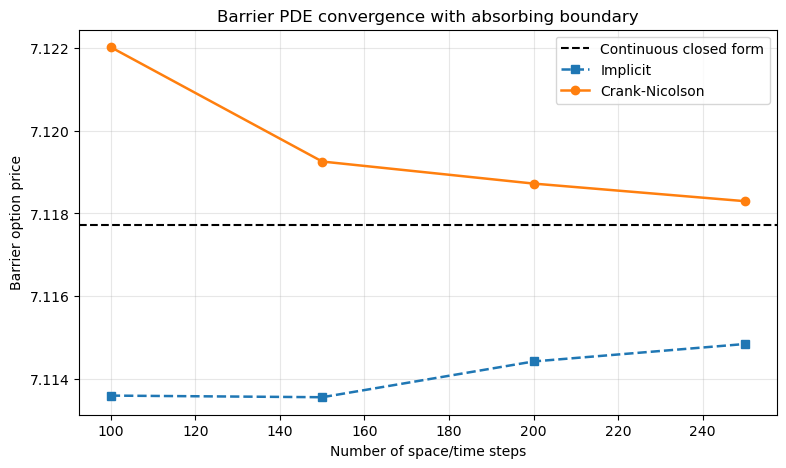

In [24]:
pde_plot_data = [
    ("Implicit", pde_implicit_df, "s", "--"),
    ("Crank-Nicolson", pde_cn_df, "o", "-"),
]

plt.figure(figsize=(9, 5))
plt.axhline(closed_form_price, color="black", linestyle="--", linewidth=1.5, label="Continuous closed form")

for label, df, marker, linestyle in pde_plot_data:
    plt.plot(
        df["No. of space steps"],
        df["Price"],
        marker=marker,
        linestyle=linestyle,
        linewidth=1.8,
        label=label,
    )

plt.xlabel("Number of space/time steps")
plt.ylabel("Barrier option price")
plt.title("Barrier PDE convergence with absorbing boundary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURE_DIR / "barrier_pde_convergence.png", dpi=200, bbox_inches="tight")
plt.show()
